# 两个 2R 手指抓取圆：逐条约束教学版
参考 `grasping_synthesis.py::generate_single_grasp` 的写法：先写符号公式，再 `lambdify`，最后 `minimize`。
两指都从 O 出发，末端杆分别为 AB、CD；四个角均可优化，第二关节角是相对角。
二维连杆没有厚度，r 是圆半径，单位 m；代码中的角度单位 rad。
主课内容到“二维可视化”为止；MuJoCo、Jacobian 和力矩控制放在后面的选学部分。
每条约束的定义单独占一个代码 cell。没有类、通用问题封装或多初值调度。
修改参数、模式或初值后，重跑参数 cell 至求解/绘图；原 notebook 不受影响。

In [32]:
import numpy as np
import sympy as sy
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from IPython.display import display
from pathlib import Path

## 1. 参数：只改这一格
`fix_center=False`：优化四个关节角以及圆心 x、y。
`fix_center=True`：只优化四个角，圆心始终等于 center。
固定圆心可能不可达；初值会影响结果，SLSQP 不保证全局最优或枚举全部解。

In [33]:
lengths = [0.12, 0.10, 0.12, 0.10]
radius = 0.035
mu = 0.6
clearance = 0.001  # 线段避碰安全间隙，不是连杆厚度
fix_center = False
center = np.array([0.14, 0.0])
q_init = np.deg2rad([35, -35, -35, 35])
center_init = np.array([0.14, 0.0])

## 2. 正运动学
$$A=l_{00}e(q_{00}),\quad B=A+l_{01}e(q_{00}+q_{01}),\quad e(a)=[\cos a,\sin a]^T.$$
C、D 同理。注意 AB 的绝对方向是两个角之和。

In [34]:
q00, q01, q10, q11, x, y = sy.symbols('q_00 q_01 q_10 q_11 x y', real=True)
l00, l01, l10, l11, r = sy.symbols('l_00 l_01 l_10 l_11 r', positive=True)
q = [q00, q01, q10, q11]
z = q + [x, y]
O = sy.Matrix([0, 0])
A = l00*sy.Matrix([sy.cos(q00), sy.sin(q00)])
B = A+l01*sy.Matrix([sy.cos(q00+q01), sy.sin(q00+q01)])
C = l10*sy.Matrix([sy.cos(q10), sy.sin(q10)])
D = C+l11*sy.Matrix([sy.cos(q10+q11), sy.sin(q10+q11)])
M = sy.Matrix([x, y])
display(A, B, C, D)

Matrix([
[l_00*cos(q_00)],
[l_00*sin(q_00)]])

Matrix([
[l_00*cos(q_00) + l_01*cos(q_00 + q_01)],
[l_00*sin(q_00) + l_01*sin(q_00 + q_01)]])

Matrix([
[l_10*cos(q_10)],
[l_10*sin(q_10)]])

Matrix([
[l_10*cos(q_10) + l_11*cos(q_10 + q_11)],
[l_10*sin(q_10) + l_11*sin(q_10 + q_11)]])

## 3. 垂足 N1、N2
$$t_1=\frac{(M-A)^T(B-A)}{l_{01}^2},\qquad N_1=A+t_1(B-A).$$
t=0 对应近端，t=1 对应远端；0≤t≤1 才在线段上。相切时，零厚度杆的接触点就是 N。
得到垂足后，直接用两点距离：
$$d_1=\sqrt{(M-N_1)^T(M-N_1)},\qquad d_2=\sqrt{(M-N_2)^T(M-N_2)}.$$
不需要另引入有符号距离 s1、s2，也不调用三角恒等式化简函数。

In [35]:
t1 = (M-A).dot(B-A)/l01**2
t2 = (M-C).dot(D-C)/l11**2
N1 = A+t1*(B-A)
N2 = C+t2*(D-C)
v1, v2 = M-N1, M-N2
# 直接计算圆心到垂足的欧氏距离。
d1 = sy.sqrt(v1.dot(v1))
d2 = sy.sqrt(v2.dot(v2))
gap1, gap2 = d1-r, d2-r

In [36]:
N2

Matrix([
[l_10*cos(q_10) + (l_11*(-l_10*sin(q_10) + y)*sin(q_10 + q_11) + l_11*(-l_10*cos(q_10) + x)*cos(q_10 + q_11))*cos(q_10 + q_11)/l_11],
[l_10*sin(q_10) + (l_11*(-l_10*sin(q_10) + y)*sin(q_10 + q_11) + l_11*(-l_10*cos(q_10) + x)*cos(q_10 + q_11))*sin(q_10 + q_11)/l_11]])

## 4. cost 与 Jacobian
沿用参考函数的距离误差平方和：$J=1000[(d_1-r)^2+(d_2-r)^2]$。
正间隙表示尚未接触，负间隙表示穿透。常数 1000 只调数值尺度，不改变最优解。
不再添加相切等式；约束禁止穿透，cost 让两侧尽量贴合。求解后还要检查实际间隙。

In [37]:
cost = (gap1**2+gap2**2)
cost_jac = sy.Matrix([cost]).jacobian(z)
# print('cost ='); sy.pprint(cost)
# print('Jacobian，列顺序 q00,q01,q10,q11,x,y ='); sy.pprint(cost_jac)
display(cost, cost_jac)

(-r + sqrt((-l_00*sin(q_00) + y - (l_01*(-l_00*sin(q_00) + y)*sin(q_00 + q_01) + l_01*(-l_00*cos(q_00) + x)*cos(q_00 + q_01))*sin(q_00 + q_01)/l_01)**2 + (-l_00*cos(q_00) + x - (l_01*(-l_00*sin(q_00) + y)*sin(q_00 + q_01) + l_01*(-l_00*cos(q_00) + x)*cos(q_00 + q_01))*cos(q_00 + q_01)/l_01)**2))**2 + (-r + sqrt((-l_10*sin(q_10) + y - (l_11*(-l_10*sin(q_10) + y)*sin(q_10 + q_11) + l_11*(-l_10*cos(q_10) + x)*cos(q_10 + q_11))*sin(q_10 + q_11)/l_11)**2 + (-l_10*cos(q_10) + x - (l_11*(-l_10*sin(q_10) + y)*sin(q_10 + q_11) + l_11*(-l_10*cos(q_10) + x)*cos(q_10 + q_11))*cos(q_10 + q_11)/l_11)**2))**2

Matrix([[2*(-r + sqrt((-l_00*sin(q_00) + y - (l_01*(-l_00*sin(q_00) + y)*sin(q_00 + q_01) + l_01*(-l_00*cos(q_00) + x)*cos(q_00 + q_01))*sin(q_00 + q_01)/l_01)**2 + (-l_00*cos(q_00) + x - (l_01*(-l_00*sin(q_00) + y)*sin(q_00 + q_01) + l_01*(-l_00*cos(q_00) + x)*cos(q_00 + q_01))*cos(q_00 + q_01)/l_01)**2))*((-l_00*sin(q_00) + y - (l_01*(-l_00*sin(q_00) + y)*sin(q_00 + q_01) + l_01*(-l_00*cos(q_00) + x)*cos(q_00 + q_01))*sin(q_00 + q_01)/l_01)*(-2*l_00*cos(q_00) - 2*(l_01*(-l_00*sin(q_00) + y)*sin(q_00 + q_01) + l_01*(-l_00*cos(q_00) + x)*cos(q_00 + q_01))*cos(q_00 + q_01)/l_01 - 2*(l_00*l_01*sin(q_00)*cos(q_00 + q_01) - l_00*l_01*sin(q_00 + q_01)*cos(q_00) + l_01*(-l_00*sin(q_00) + y)*cos(q_00 + q_01) - l_01*(-l_00*cos(q_00) + x)*sin(q_00 + q_01))*sin(q_00 + q_01)/l_01)/2 + (2*l_00*sin(q_00) + 2*(l_01*(-l_00*sin(q_00) + y)*sin(q_00 + q_01) + l_01*(-l_00*cos(q_00) + x)*cos(q_00 + q_01))*sin(q_00 + q_01)/l_01 - 2*(l_00*l_01*sin(q_00)*cos(q_00 + q_01) - l_00*l_01*sin(q_00 + q_01)*cos(q_00

## 5. 每条 constraint 一个 cell
SLSQP 的 `ineq` 约定是 **c≥0**。
c1–c4 沿用参考函数的端点点积条件；除以杆长平方后分别等于 t1、1−t1、t2、1−t2。

In [38]:
# c1：N1 不在 A 的后方，t1 >= 0。
c1 = (A-B).dot(A-M)/l01**2
display(c1)

(-l_01*(l_00*sin(q_00) - y)*sin(q_00 + q_01) - l_01*(l_00*cos(q_00) - x)*cos(q_00 + q_01))/l_01**2

In [39]:
# c2：N1 不越过 B，t1 <= 1。
c2 = (B-A).dot(B-M)/l01**2
display(c2)

(l_01*(l_00*sin(q_00) + l_01*sin(q_00 + q_01) - y)*sin(q_00 + q_01) + l_01*(l_00*cos(q_00) + l_01*cos(q_00 + q_01) - x)*cos(q_00 + q_01))/l_01**2

In [40]:
# c3：N2 不在 C 的后方，t2 >= 0。
c3 = (C-D).dot(C-M)/l11**2
display(c3)

(-l_11*(l_10*sin(q_10) - y)*sin(q_10 + q_11) - l_11*(l_10*cos(q_10) - x)*cos(q_10 + q_11))/l_11**2

In [41]:
# c4：N2 不越过 D，t2 <= 1。
c4 = (D-C).dot(D-M)/l11**2
display(c4)

(l_11*(l_10*sin(q_10) + l_11*sin(q_10 + q_11) - y)*sin(q_10 + q_11) + l_11*(l_10*cos(q_10) + l_11*cos(q_10 + q_11) - x)*cos(q_10 + q_11))/l_11**2

In [42]:
# c5：两接触方向夹角至少 90°，排除同侧夹持。
c5 = -v1.dot(v2)/r**2
display(c5)

(-(-l_00*sin(q_00) + y - (l_01*(-l_00*sin(q_00) + y)*sin(q_00 + q_01) + l_01*(-l_00*cos(q_00) + x)*cos(q_00 + q_01))*sin(q_00 + q_01)/l_01)*(-l_10*sin(q_10) + y - (l_11*(-l_10*sin(q_10) + y)*sin(q_10 + q_11) + l_11*(-l_10*cos(q_10) + x)*cos(q_10 + q_11))*sin(q_10 + q_11)/l_11) - (-l_00*cos(q_00) + x - (l_01*(-l_00*sin(q_00) + y)*sin(q_00 + q_01) + l_01*(-l_00*cos(q_00) + x)*cos(q_00 + q_01))*cos(q_00 + q_01)/l_01)*(-l_10*cos(q_10) + x - (l_11*(-l_10*sin(q_10) + y)*sin(q_10 + q_11) + l_11*(-l_10*cos(q_10) + x)*cos(q_10 + q_11))*cos(q_10 + q_11)/l_11))/r**2

摩擦锥半角 $\alpha=\arctan\mu$，因此 $\cos\alpha=1/\sqrt{1+\mu^2}$。
仿照原函数，让 N1→N2 的连线落在第一指摩擦锥内，反方向落在第二指摩擦锥内。
相切时 N 就是真实接触点；未收敛时这些条件只是对候选几何方向的限制。
分母中的 1e-24 仅防止不可行中间点除零，初值应避开圆心恰在线上或 N1=N2 的退化情况。

In [43]:
# c6：第一指摩擦锥。
c6 = v1.dot(N2-N1)/sy.sqrt(v1.dot(v1)+1e-24)/sy.sqrt((N2-N1).dot(N2-N1)+1e-24)-1/np.sqrt(1+mu**2)
display(c6)

((-l_00*sin(q_00) + y - (l_01*(-l_00*sin(q_00) + y)*sin(q_00 + q_01) + l_01*(-l_00*cos(q_00) + x)*cos(q_00 + q_01))*sin(q_00 + q_01)/l_01)*(-l_00*sin(q_00) + l_10*sin(q_10) + (l_11*(-l_10*sin(q_10) + y)*sin(q_10 + q_11) + l_11*(-l_10*cos(q_10) + x)*cos(q_10 + q_11))*sin(q_10 + q_11)/l_11 - (l_01*(-l_00*sin(q_00) + y)*sin(q_00 + q_01) + l_01*(-l_00*cos(q_00) + x)*cos(q_00 + q_01))*sin(q_00 + q_01)/l_01) + (-l_00*cos(q_00) + x - (l_01*(-l_00*sin(q_00) + y)*sin(q_00 + q_01) + l_01*(-l_00*cos(q_00) + x)*cos(q_00 + q_01))*cos(q_00 + q_01)/l_01)*(-l_00*cos(q_00) + l_10*cos(q_10) + (l_11*(-l_10*sin(q_10) + y)*sin(q_10 + q_11) + l_11*(-l_10*cos(q_10) + x)*cos(q_10 + q_11))*cos(q_10 + q_11)/l_11 - (l_01*(-l_00*sin(q_00) + y)*sin(q_00 + q_01) + l_01*(-l_00*cos(q_00) + x)*cos(q_00 + q_01))*cos(q_00 + q_01)/l_01))/(sqrt((-l_00*sin(q_00) + y - (l_01*(-l_00*sin(q_00) + y)*sin(q_00 + q_01) + l_01*(-l_00*cos(q_00) + x)*cos(q_00 + q_01))*sin(q_00 + q_01)/l_01)**2 + (-l_00*cos(q_00) + x - (l_01*(-l_00*s

In [44]:
# c7：第二指摩擦锥。
c7 = v2.dot(N1-N2)/sy.sqrt(v2.dot(v2)+1e-24)/sy.sqrt((N2-N1).dot(N2-N1)+1e-24)-1/np.sqrt(1+mu**2)
display(c7)

((-l_10*sin(q_10) + y - (l_11*(-l_10*sin(q_10) + y)*sin(q_10 + q_11) + l_11*(-l_10*cos(q_10) + x)*cos(q_10 + q_11))*sin(q_10 + q_11)/l_11)*(l_00*sin(q_00) - l_10*sin(q_10) - (l_11*(-l_10*sin(q_10) + y)*sin(q_10 + q_11) + l_11*(-l_10*cos(q_10) + x)*cos(q_10 + q_11))*sin(q_10 + q_11)/l_11 + (l_01*(-l_00*sin(q_00) + y)*sin(q_00 + q_01) + l_01*(-l_00*cos(q_00) + x)*cos(q_00 + q_01))*sin(q_00 + q_01)/l_01) + (-l_10*cos(q_10) + x - (l_11*(-l_10*sin(q_10) + y)*sin(q_10 + q_11) + l_11*(-l_10*cos(q_10) + x)*cos(q_10 + q_11))*cos(q_10 + q_11)/l_11)*(l_00*cos(q_00) - l_10*cos(q_10) - (l_11*(-l_10*sin(q_10) + y)*sin(q_10 + q_11) + l_11*(-l_10*cos(q_10) + x)*cos(q_10 + q_11))*cos(q_10 + q_11)/l_11 + (l_01*(-l_00*sin(q_00) + y)*sin(q_00 + q_01) + l_01*(-l_00*cos(q_00) + x)*cos(q_00 + q_01))*cos(q_00 + q_01)/l_01))/(sqrt((-l_10*sin(q_10) + y - (l_11*(-l_10*sin(q_10) + y)*sin(q_10 + q_11) + l_11*(-l_10*cos(q_10) + x)*cos(q_10 + q_11))*sin(q_10 + q_11)/l_11)**2 + (-l_10*cos(q_10) + x - (l_11*(-l_10*sin

In [45]:
# c8：AB 不穿入圆，d1 >= r。
c8 = gap1/r
display(c8)

(-r + sqrt((-l_00*sin(q_00) + y - (l_01*(-l_00*sin(q_00) + y)*sin(q_00 + q_01) + l_01*(-l_00*cos(q_00) + x)*cos(q_00 + q_01))*sin(q_00 + q_01)/l_01)**2 + (-l_00*cos(q_00) + x - (l_01*(-l_00*sin(q_00) + y)*sin(q_00 + q_01) + l_01*(-l_00*cos(q_00) + x)*cos(q_00 + q_01))*cos(q_00 + q_01)/l_01)**2))/r

In [46]:
# c9：CD 不穿入圆，d2 >= r。
c9 = gap2/r
display(c9)

(-r + sqrt((-l_10*sin(q_10) + y - (l_11*(-l_10*sin(q_10) + y)*sin(q_10 + q_11) + l_11*(-l_10*cos(q_10) + x)*cos(q_10 + q_11))*sin(q_10 + q_11)/l_11)**2 + (-l_10*cos(q_10) + x - (l_11*(-l_10*sin(q_10) + y)*sin(q_10 + q_11) + l_11*(-l_10*cos(q_10) + x)*cos(q_10 + q_11))*cos(q_10 + q_11)/l_11)**2))/r

近端 OA、OC 也要避开圆。点到有限线段的最近点可以把投影参数截断到 [0,1]。
与原函数只有一根中间避碰杆不同，本机器人需要分别检查两根近端杆。

In [47]:
# c10：圆与 OA 保持 clearance。
t_OA = sy.Min(1, sy.Max(0, M.dot(A)/l00**2))
H_OA = t_OA*A
c10 = (sy.sqrt((M-H_OA).dot(M-H_OA))-r-clearance)/l00
display(c10)

(-r + sqrt((-l_00*sin(q_00)*Min(1, Max(0, (l_00*x*cos(q_00) + l_00*y*sin(q_00))/l_00**2)) + y)**2 + (-l_00*cos(q_00)*Min(1, Max(0, (l_00*x*cos(q_00) + l_00*y*sin(q_00))/l_00**2)) + x)**2) - 0.001)/l_00

In [48]:
# c11：圆与 OC 保持 clearance。
t_OC = sy.Min(1, sy.Max(0, M.dot(C)/l10**2))
H_OC = t_OC*C
c11 = (sy.sqrt((M-H_OC).dot(M-H_OC))-r-clearance)/l10
display(c11)

(-r + sqrt((-l_10*sin(q_10)*Min(1, Max(0, (l_10*x*cos(q_10) + l_10*y*sin(q_10))/l_10**2)) + y)**2 + (-l_10*cos(q_10)*Min(1, Max(0, (l_10*x*cos(q_10) + l_10*y*sin(q_10))/l_10**2)) + x)**2) - 0.001)/l_10

## 6. 代入数值，转换成 NumPy 函数
固定圆心时直接代入 x、y，优化变量只剩四个角；这不是圆心位置的软惩罚。
约束用 SLSQP 数值差分即可，cost 使用上面打印的解析 Jacobian。

In [49]:
subs = dict(zip([l00,l01,l10,l11,r], [*lengths,radius]))
variables = z
initial = np.r_[q_init,center_init]
reach = max(lengths[0]+lengths[1],lengths[2]+lengths[3])+radius
bounds = [(-np.pi,np.pi)]*4 + [(-reach,reach)]*2
if fix_center:
    subs.update({x:float(center[0]),y:float(center[1])})
    variables = q
    initial = q_init.copy()
    bounds = bounds[:4]

cost_num = sy.lambdify([variables],cost.subs(subs),'numpy',cse=True)
jac_expr = sy.Matrix([cost.subs(subs)]).jacobian(variables)
jac_num = sy.lambdify([variables],jac_expr,'numpy',cse=True)
print('本次优化变量：',variables)
print('本次 cost：'); sy.pprint(cost.subs(subs))
print('本次 Jacobian：'); sy.pprint(jac_expr)
c_expr = [c1,c2,c3,c4,c5,c6,c7,c8,c9,c10,c11]
c_num = [sy.lambdify([variables],c.subs(subs),'numpy',cse=True) for c in c_expr]
gap_num = sy.lambdify([variables],[gap1.subs(subs),gap2.subs(subs)],'numpy',cse=True)
fk = sy.lambdify([variables],sy.Matrix.hstack(O,A,B,C,D,M,N1,N2).subs(subs),'numpy',cse=True)

本次优化变量： [q_00, q_01, q_10, q_11, x, y]
本次 cost：
                                                                               ↪
⎛   __________________________________________________________________________ ↪
⎜  ╱                                                                           ↪
⎝╲╱  (x - 10.0⋅(0.1⋅(x - 0.12⋅cos(q₀₀))⋅cos(q₀₀ + q₀₁) + 0.1⋅(y - 0.12⋅sin(q₀₀ ↪

↪                                                                              ↪
↪ ____________________________________________________________________________ ↪
↪                                                   2                          ↪
↪ ))⋅sin(q₀₀ + q₀₁))⋅cos(q₀₀ + q₀₁) - 0.12⋅cos(q₀₀))  + (y - 10.0⋅(0.1⋅(x - 0. ↪

↪                                                                              ↪
↪ ____________________________________________________________________________ ↪
↪                                                                              ↪
↪ 12⋅cos(q₀₀))⋅cos(q₀₀ + q₀₁) + 0.1⋅(y - 0.12⋅sin(q₀₀))⋅sin

In [50]:
cost

(-r + sqrt((-l_00*sin(q_00) + y - (l_01*(-l_00*sin(q_00) + y)*sin(q_00 + q_01) + l_01*(-l_00*cos(q_00) + x)*cos(q_00 + q_01))*sin(q_00 + q_01)/l_01)**2 + (-l_00*cos(q_00) + x - (l_01*(-l_00*sin(q_00) + y)*sin(q_00 + q_01) + l_01*(-l_00*cos(q_00) + x)*cos(q_00 + q_01))*cos(q_00 + q_01)/l_01)**2))**2 + (-r + sqrt((-l_10*sin(q_10) + y - (l_11*(-l_10*sin(q_10) + y)*sin(q_10 + q_11) + l_11*(-l_10*cos(q_10) + x)*cos(q_10 + q_11))*sin(q_10 + q_11)/l_11)**2 + (-l_10*cos(q_10) + x - (l_11*(-l_10*sin(q_10) + y)*sin(q_10 + q_11) + l_11*(-l_10*cos(q_10) + x)*cos(q_10 + q_11))*cos(q_10 + q_11)/l_11)**2))**2

## 7. 三条非相邻线段避碰约束
下面两个短函数只用于计算距离，不封装优化器。线段相交时距离为零。
clearance 必须为正，否则“距离≥0”不能排除相交。
OA 与 OC 共用 O，不检查这一对；同指相邻杆允许共用关节点。

In [51]:
def point_segment_distance(p,a,b):
    t = np.clip(np.dot(p-a,b-a)/np.dot(b-a,b-a),0,1)
    return np.linalg.norm(p-a-t*(b-a))

def segment_distance(a,b,c,d):
    cross = lambda u,v: u[0]*v[1]-u[1]*v[0]
    den = cross(b-a,d-c)
    if abs(den)>1e-14:
        t,s = cross(c-a,d-c)/den,cross(c-a,b-a)/den
        if 0<=t<=1 and 0<=s<=1:
            return 0.
    return min(point_segment_distance(a,c,d),point_segment_distance(b,c,d),
               point_segment_distance(c,a,b),point_segment_distance(d,a,b))

In [52]:
# c12：OA 与 CD 保持安全间隙。
def c12(u):
    p = np.asarray(fk(u),dtype=float).T
    return (segment_distance(p[0],p[1],p[3],p[4])-clearance)/lengths[0]

In [53]:
# c13：OC 与 AB 保持安全间隙。
def c13(u):
    p = np.asarray(fk(u),dtype=float).T
    return (segment_distance(p[0],p[3],p[1],p[2])-clearance)/lengths[0]

In [54]:
# c14：AB 与 CD 保持安全间隙。
def c14(u):
    p = np.asarray(fk(u),dtype=float).T
    return (segment_distance(p[1],p[2],p[3],p[4])-clearance)/lengths[0]

## 8. 一次 SLSQP 求解
接近参考函数结尾：把每个 c 加到 cons，直接调用 minimize。
只有求解成功、所有 c≥−1e-7、两侧间隙绝对值小于 1e-6 m，才接受为抓取解。

In [55]:
constraint_functions = c_num+[c12,c13,c14]
cons = [{'type':'ineq','fun':f} for f in constraint_functions]
res = minimize(lambda u:float(cost_num(u)),initial,
               jac=lambda u:np.asarray(jac_num(u),dtype=float).ravel(),
               method='SLSQP',bounds=bounds,constraints=cons,
               options={'maxiter':500,'ftol':1e-12,'disp':True})
values = np.array([f(res.x) for f in constraint_functions],dtype=float)
gaps = np.asarray(gap_num(res.x),dtype=float)
print('两侧间隙 [m]：',gaps)
for i,value in enumerate(values,1):
    print(f'c{i} = {value:.6g}')
assert res.success and values.min()>=-1e-7 and np.max(np.abs(gaps))<1e-6, '未得到合格抓取，请修改初值/圆心。'
q_goal = res.x[:4].copy()
M_goal = center.copy() if fix_center else res.x[4:6].copy()
p = np.asarray(fk(res.x),dtype=float).T
print('q [deg]：',np.rad2deg(q_goal))
print('圆心 [m]：',M_goal)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 7.145911201292047e-19
            Iterations: 7
            Function evaluations: 8
            Gradient evaluations: 7
两侧间隙 [m]： [5.95214059e-10 6.00259398e-10]
c1 = 0.795867
c2 = 0.204133
c3 = 0.795867
c4 = 0.204133
c5 = 0.905835
c6 = 0.118682
c7 = 0.118682
c8 = 1.70061e-08
c9 = 1.71503e-08
c10 = 0.424523
c11 = 0.424523
c12 = 0.76618
c13 = 0.76618
c14 = 0.487279
q [deg]： [ 25.38046691 -37.91249084 -25.38046691  37.91249084]
圆心 [m]： [1.78513811e-01 4.06917925e-12]


## 9. 二维可视化
虚线是初值，实线是结果；红点是相切处 N1、N2。
主课到这里即可。切换 fix_center 或修改初值后，重跑参数至此处。

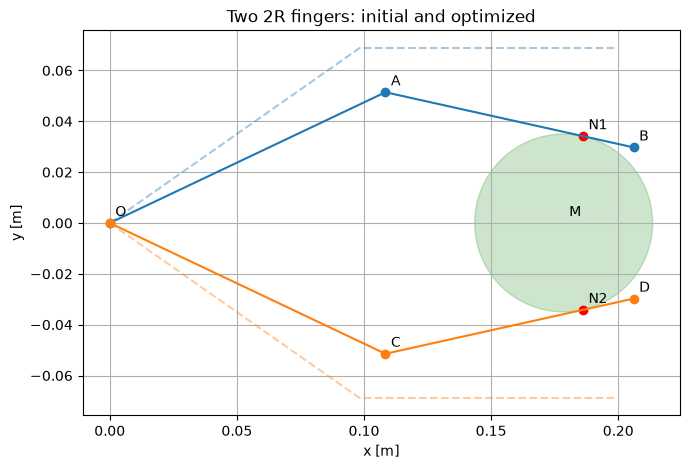

In [63]:
p0 = np.asarray(fk(initial),dtype=float).T
fig,ax = plt.subplots(figsize=(8,5))
for ids,color in [([0,1,2],'C0'),([0,3,4],'C1')]:
    ax.plot(p0[ids,0],p0[ids,1],'--',color=color,alpha=.4)
    ax.plot(p[ids,0],p[ids,1],'-o',color=color)
ax.add_patch(plt.Circle(M_goal,radius,color='green',alpha=.2))
ax.scatter(p[6:8,0],p[6:8,1],color='red')
for name,xy in zip(['O','A','B','C','D','M','N1','N2'],p):
    ax.annotate(name,xy,xytext=(4,5),textcoords='offset points')
ax.set(aspect='equal',xlabel='x [m]',ylabel='y [m]',title='Two 2R fingers: initial and optimized')
ax.grid(True)
out = Path('grasping_simple_output');out.mkdir(exist_ok=True)
fig.savefig(out/'planar_grasp.png',dpi=140)
plt.show()

## 10. 选学：MuJoCo 模型
四个 hinge、四个力矩 motor，地面 z=-0.1m；圆柱位置由 mocap 固定。
二维杆无厚度。MuJoCo 碰撞杆取极小半径 eta，圆柱碰撞半径取 r−eta，所以相切距离仍是 r。
可见杆、可见圆柱不参与碰撞；杆质量独立给定，不随 eta 缩为零。
接触 site 直接放在远端杆上，后面可以直接用 mj_jacSite，不需要处理独立标记。
如果只改优化初值或圆心，求解后重跑“更新显示”即可；改杆长/半径时要重建模型。

In [64]:
import mujoco
import mujoco.viewer
import time
eta, visual_radius, mass = 1e-5, 0.0015, 0.02
assert radius>eta
if 'viewer' in globals() and viewer is not None:
    viewer.close()
viewer = None
finger_xml = ''
for i,(a,b,color) in enumerate([(lengths[0],lengths[1],'0.2 0.4 0.9 1'),(lengths[2],lengths[3],'0.9 0.5 0.1 1')]):
    finger_xml += f'''
    <body name="finger{i}">
      <inertial pos="{a/2} 0 0" mass="{mass}" diaginertia="1e-8 {mass*a*a/12} {mass*a*a/12}"/>
      <joint name="q{i}0" axis="0 0 1"/>
      <geom type="capsule" fromto="0 0 0 {a} 0 0" size="{eta}" rgba="0 0 0 0"/>
      <geom type="capsule" fromto="0 0 0 {a} 0 0" size="{visual_radius}" rgba="{color}" contype="0" conaffinity="0"/>
      <body name="distal{i}" pos="{a} 0 0">
        <inertial pos="{b/2} 0 0" mass="{mass}" diaginertia="1e-8 {mass*b*b/12} {mass*b*b/12}"/>
        <joint name="q{i}1" axis="0 0 1"/>
        <geom name="contact_link{i}" type="capsule" fromto="0 0 0 {b} 0 0" size="{eta}" rgba="0 0 0 0"/>
        <geom type="capsule" fromto="0 0 0 {b} 0 0" size="{visual_radius}" rgba="{color}" contype="0" conaffinity="0"/>
        <site name="N{i+1}" pos="{b/2} 0 0" size="0.002" rgba="1 0 0 1"/>
      </body>
    </body>'''
xml = f'''<mujoco>
  <compiler angle="radian"/>
  <option timestep="0.0005" gravity="0 0 -9.81"/>
  <default><joint type="hinge" damping="0.002" limited="true" range="-3.141593 3.141593"/><geom friction="{mu} 0.005 0.0001"/></default>
  <asset><texture name="checker" type="2d" builtin="checker" rgb1=".8 .8 .8" rgb2=".3 .3 .3" width="256" height="256"/>
  <material name="floor" texture="checker" texrepeat="10 10"/></asset>
  <worldbody><light pos="0 0 1"/>
    <geom type="plane" pos="0 0 -0.1" size="1 1 .01" material="floor"/>
    {finger_xml}
    <body name="object" mocap="true" pos="{M_goal[0]} {M_goal[1]} 0">
      <geom name="cylinder" type="cylinder" size="{radius-eta} .04" rgba="0 0 0 0"/>
      <geom type="cylinder" size="{radius} .04" rgba=".2 .7 .3 .8" contype="0" conaffinity="0"/>
    </body>
  </worldbody>
  <contact><exclude body1="finger0" body2="finger1"/></contact>
  <actuator>{''.join(f'<motor joint="{name}" gear="1" ctrllimited="true" ctrlrange="-.8 .8"/>' for name in ['q00','q01','q10','q11'])}</actuator>
</mujoco>'''
model = mujoco.MjModel.from_xml_string(xml)
data = mujoco.MjData(model)

### 更新显示：优化完成后重跑这一格
零厚度接触点 N=A+a*e(theta)；a 是远端杆上的材料坐标。
初次运行无需 viewer；打开窗口后也能在原窗口更新。

In [65]:
from contextlib import nullcontext
live = viewer is not None and viewer.is_running()
with viewer.lock() if live else nullcontext():
    data.qpos[:] = q_goal
    data.qvel[:] = 0
    data.ctrl[:] = 0
    data.mocap_pos[0] = [*M_goal,0.]
    model.site('N1').pos[:] = [np.linalg.norm(p[6]-p[1]),0,0]
    model.site('N2').pos[:] = [np.linalg.norm(p[7]-p[3]),0,0]
    mujoco.mj_forward(model,data)
if live:
    viewer.sync()

### 打开 passive viewer
此 cell 立即返回，不写无限循环。关闭窗口后可以重跑；自动验证时跳过。

In [66]:
if viewer is None or not viewer.is_running():
    viewer = mujoco.viewer.launch_passive(model,data)
    with viewer.lock():
        viewer.cam.lookat[:] = [.12,0,0]
        viewer.cam.distance = .5
        viewer.cam.azimuth,viewer.cam.elevation = 90,-65
    viewer.sync()

## 11. 选学：接触 Jacobian 与附加力矩
材料点速度 $\dot P_i=J_i\dot q$，通过虚功得到 $\tau_i=J_i^Tf_i$。
每侧夹持力大小为 F，两侧沿接触点连线施加等大反向力；世界坐标中的 f 表示手指对物体的力。
对手指的反力是 −f，所以电机增加 +Jᵀf 来抵抗它。
注意这是杆上固定材料点的 Jacobian，不是对随圆心移动的垂足公式直接求导。

In [70]:
F = 10  # 每侧 N
J1 = np.zeros((3,model.nv))
J2 = np.zeros((3,model.nv))
# 独立 data 用于计算目标姿态 Jacobian，不扰动已打开的 viewer。
goal_data = mujoco.MjData(model)
goal_data.qpos[:] = q_goal
mujoco.mj_forward(model,goal_data)
mujoco.mj_jacSite(model,goal_data,J1,None,model.site('N1').id)
mujoco.mj_jacSite(model,goal_data,J2,None,model.site('N2').id)
direction = np.r_[p[7]-p[6],0.]
direction /= np.linalg.norm(direction)
f1,f2 = F*direction,-F*direction
tau_extra = J1.T@f1+J2.T@f2
print('J1_xy =\n',J1[:2])
print('J2_xy =\n',J2[:2])
print('附加力矩 [N m] =',tau_extra)

J1_xy =
 [[-0.03416612  0.01726914  0.          0.        ]
 [ 0.18610829  0.07769052  0.          0.        ]]
J2_xy =
 [[ 0.          0.          0.03416612 -0.01726914]
 [ 0.          0.          0.18610829  0.07769052]]
附加力矩 [N m] = [-1.86108295 -0.77690518  1.86108295  0.77690518]


## 12. 选学：计算力矩 + PD + JᵀF（有限时长实验）
$$\tau=M(q)[\ddot q_d+K_d(\dot q_d-\dot q)+K_p(q_d-q)]+b-\tau_{passive}+J_1^Tf_1+J_2^Tf_2.$$
这里直接跟踪常值 q_goal，所以期望速度、加速度为零。从附近张开的姿态开始，1 秒后缓慢加夹持力。
F 是力前馈，不是闭环力控制；实际接触力与 F 可以不同。圆柱固定，本例不是自由物体抓取稳定性验证。
默认离线运行并画图；先打开 viewer、将 realtime=True，可观察 3 秒动力学过程。
接触点按目标材料坐标固定，适合本例小位移跟踪；大范围滑动/滚动需要重新定位接触点。
改 F 后重跑第 11 节及本 cell；重新优化后先重跑“更新显示”和第 11 节。

In [71]:
realtime = False
Kp,Kd = 40000.,400.
live = viewer is not None and viewer.is_running()
with viewer.lock() if live else nullcontext():
    mujoco.mj_resetData(model,data)
    data.mocap_pos[0] = [*M_goal,0.]
    data.qpos[:] = q_goal+np.deg2rad([2,0,-2,0])
    mujoco.mj_forward(model,data)
times,angles,torques,extra_torques,normal_forces = [],[],[],[],[]
mass_matrix = np.zeros((4,4))
start_time = time.perf_counter()
for k in range(int(3/model.opt.timestep)):
    if live and not viewer.is_running():
        break
    with viewer.lock() if live else nullcontext():
        mujoco.mj_forward(model,data)
        try:  # MuJoCo 3.10+ / 旧版本
            mujoco.mj_fullM(model,data,mass_matrix)
        except TypeError:
            mujoco.mj_fullM(model,mass_matrix,data.qM)
        tau_pd = mass_matrix@(Kp*(q_goal-data.qpos)-Kd*data.qvel)+data.qfrc_bias-data.qfrc_passive
        mujoco.mj_jacSite(model,data,J1,None,model.site('N1').id)
        mujoco.mj_jacSite(model,data,J2,None,model.site('N2').id)
        ramp = np.clip((data.time-1.)/.5,0,1)
        tau_force = ramp*(J1.T@f1+J2.T@f2)
        data.ctrl[:] = np.clip(tau_pd+tau_force,-.8,.8)
        mujoco.mj_forward(model,data)
        if k%10==0:
            measured = np.zeros(2)
            for contact_id in range(data.ncon):
                pair = set(data.contact[contact_id].geom)
                for i in range(2):
                    if pair=={model.geom('cylinder').id,model.geom(f'contact_link{i}').id}:
                        wrench = np.zeros(6)
                        mujoco.mj_contactForce(model,data,contact_id,wrench)
                        measured[i] += max(0,wrench[0])
            times.append(data.time);angles.append(data.qpos.copy())
            torques.append(data.ctrl.copy());extra_torques.append(tau_force.copy());normal_forces.append(measured)
        mujoco.mj_step(model,data)
    if live and k%30==0:
        viewer.sync()
    if realtime and k%30==0:
        time.sleep(max(0,data.time-(time.perf_counter()-start_time)))
if live and viewer.is_running():
    viewer.sync()
print('最终角误差 [deg]：',np.rad2deg(q_goal-data.qpos))
print('实测法向力 [N]：',normal_forces[-1])

最终角误差 [deg]： [-18.47761169  35.27432576  18.45915231 -35.23311229]
实测法向力 [N]： [4.52556538 4.5259824 ]


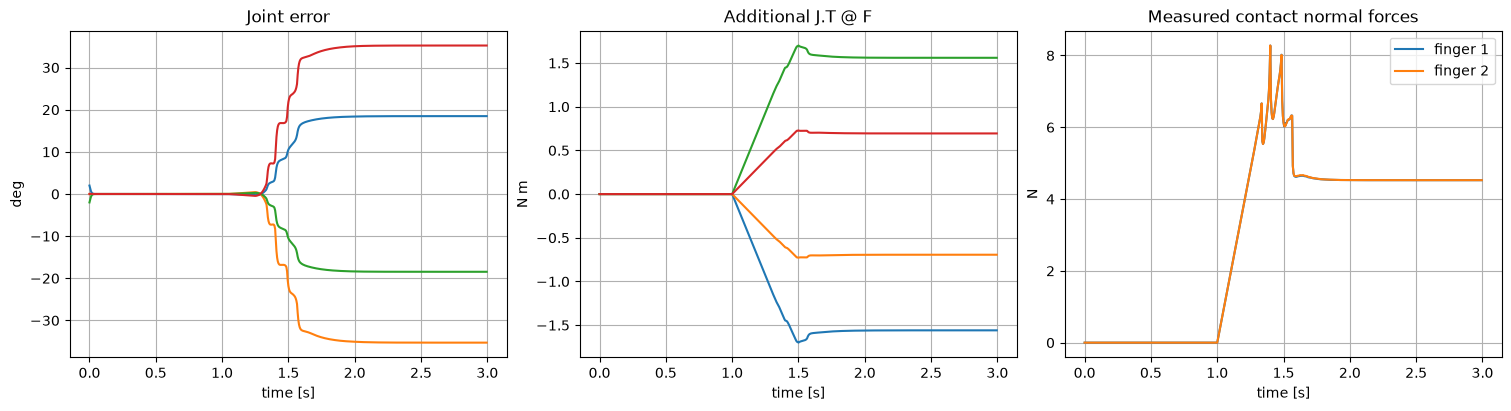

In [72]:
fig,axes = plt.subplots(1,3,figsize=(15,4),constrained_layout=True)
axes[0].plot(times,np.rad2deg(np.asarray(angles)-q_goal))
axes[0].set(title='Joint error',ylabel='deg')
axes[1].plot(times,extra_torques)
axes[1].set(title='Additional J.T @ F',ylabel='N m')
axes[2].plot(times,normal_forces,label=['finger 1','finger 2'])
axes[2].set(title='Measured contact normal forces',ylabel='N')
for ax in axes:
    ax.set_xlabel('time [s]');ax.grid(True)
axes[2].legend()
fig.savefig(out/'torque_control.png',dpi=140)
plt.show()
# 结束课堂后可运行 viewer.close()；这里不自动关闭。